In [1]:
# ==========================================
# Cell 1: 基础设置与随机种子 (Random Seed)
# ==========================================
import os
import random
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[Info] Global Random Seed set to: {seed}")

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[Info] Using device: {device}")

[Info] Global Random Seed set to: 42
[Info] Using device: cpu


In [2]:
# ==========================================
# Cell 2: 数据集与预处理函数包装
# ==========================================
ALPHABET = 'ABCDEFGHIKLMNOPQRSTUVWXY' # 24 个手势字母 (跳过 J 和 Z)

def build_transforms(img_size=32):
    """
    数据预处理函数包装：Resize 到 32x32，并扩展为 3 通道归一化输入
    """
    train_transform = T.Compose([
        T.ToPILImage(),
        T.Resize((img_size, img_size)),
        T.RandomRotation(10),
        T.ToTensor(),
        T.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = T.Compose([
        T.ToPILImage(),
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return train_transform, val_transform

class SignDatasetViT(Dataset):
    def __init__(self, df, transform=None):
        self.raw_labels = df['label'].values
        unique_labels = sorted(np.unique(self.raw_labels))
        self.label_to_idx = {l: i for i, l in enumerate(unique_labels)}
        self.idx_to_char = {i: ALPHABET[i] for i in range(len(unique_labels))}
        
        self.labels = np.array([self.label_to_idx[l] for l in self.raw_labels])
        self.images = df.drop('label', axis=1).values.reshape(-1, 28, 28).astype(np.uint8)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

def prepare_dataloaders(train_csv, test_csv, batch_size=128, img_size=32):
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    train_tf, val_tf = build_transforms(img_size)
    
    train_set = SignDatasetViT(train_df, transform=train_tf)
    test_set = SignDatasetViT(test_df, transform=val_tf)
    
    train_dl = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_dl = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_dl, test_dl, train_set, test_set

train_csv_path = "/home/zhang/projects/gesture-classsification/dataset/sign_mnist_train.csv"
test_csv_path = "/home/zhang/projects/gesture-classsification/dataset/sign_mnist_test.csv"

train_dl, test_dl, train_set, test_set = prepare_dataloaders(train_csv_path, test_csv_path, batch_size=128)
label_mapping = test_set.idx_to_char

In [3]:
# ==========================================
# Cell 3: ViT 模型类定义与通用训练/评估函数
# ==========================================
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class FlexibleSignViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=24, 
                 embed_dim=128, depth=4, num_heads=4, mlp_ratio=2.0, dropout=0.1, model_name="ViT-Base"):
        super().__init__()
        self.model_name = model_name
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = x + self.pos_drop(x)
        x = self.blocks(x)
        x = self.norm(x)
        return self.fc(x[:, 0])

# 可视化 Top-5 推理结果函数
def predict_and_plot_top5(model, dataset, sample_idx=0, label_map=None, title_prefix="Inference"):
    model.eval()
    img_tensor, true_label_idx = dataset[sample_idx]
    
    input_tensor = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1).squeeze(0)
    
    top5_probs, top5_indices = torch.topk(probs, 5)
    top5_probs = top5_probs.cpu().numpy()
    top5_indices = top5_indices.cpu().numpy()
    
    # 反归一化图像
    img_np = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    
    # 左图：图片与真实标签
    ax1.imshow(img_np)
    true_char = label_map[true_label_idx.item()] if label_map else str(true_label_idx.item())
    ax1.set_title(f"Input Image (Sample #{sample_idx})\nTrue Label: '{true_char}'")
    ax1.axis('off')
    
    # 右图：Top-5 柱状图
    labels_top5 = [f"'{label_map[idx]}'" for idx in top5_indices] if label_map else top5_indices
    y_pos = np.arange(len(labels_top5))
    
    bars = ax2.barh(y_pos, top5_probs * 100, align='center', color='teal')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels_top5)
    ax2.invert_yaxis()
    ax2.set_xlabel('Confidence / Probability (%)')
    ax2.set_xlim(0, 115)
    ax2.set_title(f"Model Name: {model.model_name}\n{title_prefix} - Top-5 Predictions")
    
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 1.5, bar.get_y() + bar.get_height()/2, f"{width:.2f}%", 
                 va='center', ha='left', fontsize=9, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

In [4]:
# 定义 Checkpoint 保存目录
CHECKPOINT_DIR = "./checkpoints"

# 如果文件夹不存在，则自动创建
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"[Info] Checkpoint 目录已准备就绪: {os.path.abspath(CHECKPOINT_DIR)}")

def save_checkpoint(model, optimizer, epoch, loss, acc, label_mapping, filename):
    """
    保存完整的 Checkpoint 到指定文件夹
    """
    filepath = os.path.join(CHECKPOINT_DIR, filename)
    checkpoint = {
        'epoch': epoch,
        'model_name': getattr(model, 'model_name', 'VisionTransformer'),
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'acc': acc,
        'label_mapping': label_mapping  # 确保 Label Mapping 与 Checkpoint 一致
    }
    torch.save(checkpoint, filepath)
    print(f"--> [Checkpoint] 已保存至: {filepath} (Acc: {acc*100:.2f}%)")

[Info] Checkpoint 目录已准备就绪: /home/zhang/projects/gesture-classsification/code/checkpoints


===== 开始训练基础模型 (Stage 1 Training) =====


Stage 1 Epoch 1/3:   0%|          | 0/215 [00:00<?, ?it/s]

Stage 1 Epoch 1/3: 100%|██████████| 215/215 [02:17<00:00,  1.56it/s]


Epoch 1 - Loss: 2.2081, Acc: 29.85%
--> [Checkpoint] 已保存至: ./checkpoints/vit_stage1_best.pth (Acc: 29.85%)


Stage 1 Epoch 2/3: 100%|██████████| 215/215 [02:09<00:00,  1.66it/s]


Epoch 2 - Loss: 0.7819, Acc: 72.64%
--> [Checkpoint] 已保存至: ./checkpoints/vit_stage1_best.pth (Acc: 72.64%)


Stage 1 Epoch 3/3: 100%|██████████| 215/215 [02:06<00:00,  1.70it/s]


Epoch 3 - Loss: 0.3886, Acc: 86.51%
--> [Checkpoint] 已保存至: ./checkpoints/vit_stage1_best.pth (Acc: 86.51%)

===== 训练后【第一次推理】 (Stage 1 Model) =====


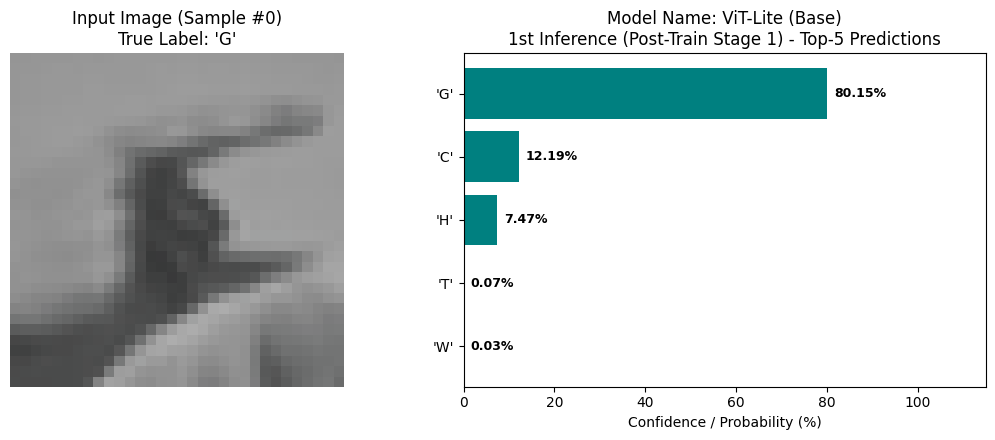

In [ ]:
# ==========================================
# Cell 4: 基础 ViT 模型训练 ➔ 记录【第一次推理】
# ==========================================
import os

# 初始轻量模型: embed_dim=128, depth=3, num_heads=4
model_v1 = FlexibleSignViT(
    img_size=32, num_classes=len(label_mapping), 
    embed_dim=128, depth=3, num_heads=4, 
    model_name="ViT-Lite (Base)"
).to(device)

criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.AdamW(model_v1.parameters(), lr=1e-3, weight_decay=0.01)

print("===== 开始训练基础模型 (Stage 1 Training) =====")
epochs = 3
best_acc_v1 = 0.0

# 统一保存的文件名与路径
ckpt_filename_v1 = "vit_stage1_best.pth"
ckpt_path_v1 = os.path.join(CHECKPOINT_DIR, ckpt_filename_v1) if 'CHECKPOINT_DIR' in globals() else ckpt_filename_v1

for epoch in range(epochs):
    model_v1.train()
    running_loss, correct, total = 0.0, 0, 0
    for data, target in tqdm(train_dl, desc=f"Stage 1 Epoch {epoch+1}/{epochs}"):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        out = model_v1(data)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * data.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == target).sum().item()
        total += target.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch+1} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc*100:.2f}%")
    
    # 刷新最佳纪录时保存到 ./checkpoints 文件夹
    if epoch_acc > best_acc_v1:
        best_acc_v1 = epoch_acc
        save_checkpoint(
            model=model_v1, 
            optimizer=optimizer, 
            epoch=epoch + 1, 
            loss=epoch_loss, 
            acc=epoch_acc, 
            label_mapping=label_mapping, 
            filename=ckpt_filename_v1
        )

# ==========================================
# 加载 Stage 1 最佳 Checkpoint 进行【第一次推理】
# ==========================================
print(f"\n--> 正在从路径加载 Stage 1 最佳 Checkpoint: {ckpt_path_v1}")
checkpoint_loaded_v1 = torch.load(ckpt_path_v1, map_location=device)

# 1. 恢复模型权重
model_v1.load_state_dict(checkpoint_loaded_v1['model_state_dict'])

# 2. 确保 Label Mapping 来自保存的 Checkpoint（验证相符性）
loaded_label_map_v1 = checkpoint_loaded_v1.get('label_mapping', label_mapping)

print(f"✅ 成功加载 Checkpoint！来自 Epoch {checkpoint_loaded_v1['epoch']}，训练准确率: {checkpoint_loaded_v1['acc']*100:.2f}%")

# ==========================================
# 打印评估摘要指标 (Parameter Count, Top-1, Top-5 Overlap)
# ==========================================
print("\n===== 训练后【第一次推理】 (Stage 1 Model) =====")

# 1. 计算参数量与模型文件大小
total_params_v1 = sum(p.numel() for p in model_v1.parameters())
file_size_mb_v1 = os.path.getsize(ckpt_path_v1) / (1024 * 1024) if os.path.exists(ckpt_path_v1) else (total_params_v1 * 4) / (1024 * 1024)

# 2. 准备推理数据 (sample_idx = 0)
model_v1.eval()
test_img_v1, ground_truth_idx_v1 = test_set[0]
test_tensor_v1 = test_img_v1.unsqueeze(0).to(device)

with torch.no_grad():
    logits_v1 = model_v1(test_tensor_v1)
    probs_v1 = torch.softmax(logits_v1, dim=1).squeeze(0)

top5_probs_v1, top5_indices_v1 = torch.topk(probs_v1, 5)
top5_indices_list_v1 = top5_indices_v1.cpu().tolist()
top5_probs_list_v1 = top5_probs_v1.cpu().tolist()

# 3. 提取 Top-1 与 Top-5 Overlap
top1_idx_v1 = top5_indices_list_v1[0]
top1_score_v1 = top5_probs_list_v1[0]
top1_label_v1 = loaded_label_map_v1.get(top1_idx_v1, str(top1_idx_v1))
gt_label_v1 = loaded_label_map_v1.get(ground_truth_idx_v1, str(ground_truth_idx_v1))
top5_overlap_v1 = ground_truth_idx_v1 in top5_indices_list_v1

# 4. 打印标准格式评估面板
print("=" * 60)
print("             STAGE 1 INFERENCE EVALUATION SUMMARY            ")
print("=" * 60)
print(f" • Parameter Count / Size : {total_params_v1:,} ({total_params_v1/1e6:.2f} M) | {file_size_mb_v1:.2f} MB")
print(f" • Ground Truth Label    : '{gt_label_v1}' (Index: {ground_truth_idx_v1})")
print(f" • Top-1 Predicted Label : '{top1_label_v1}' (Index: {top1_idx_v1})")
print(f" • Top-1 Score (Conf.)   : {top1_score_v1 * 100:.2f}% ({top1_score_v1:.4f})")
print(f" • Top-5 Overlap Status  : {'✅ Overlapped (True)' if top5_overlap_v1 else '❌ No Overlap (False)'}")
print(f" • Top-5 Pred Labels     : {[loaded_label_map_v1.get(i, str(i)) for i in top5_indices_list_v1]}")
print("=" * 60)

# 5. 可视化绘图展示
predict_and_plot_top5(model_v1, test_set, sample_idx=0, label_map=loaded_label_map_v1, title_prefix="1st Inference (Post-Train Stage 1)")


===== 开始训练改善版模型 (Stage 2 Improved Training) =====


Stage 2 Epoch 1/3:   0%|          | 0/215 [00:00<?, ?it/s]

Stage 2 Epoch 1/3: 100%|██████████| 215/215 [06:12<00:00,  1.73s/it]


Improved Epoch 1 - Loss: 2.6043, Acc: 21.90%
--> [Checkpoint] 已保存至: ./checkpoints/vit_stage2_improved_best.pth (Acc: 21.90%)


Stage 2 Epoch 2/3: 100%|██████████| 215/215 [06:09<00:00,  1.72s/it]


Improved Epoch 2 - Loss: 1.3486, Acc: 69.17%
--> [Checkpoint] 已保存至: ./checkpoints/vit_stage2_improved_best.pth (Acc: 69.17%)


Stage 2 Epoch 3/3: 100%|██████████| 215/215 [06:19<00:00,  1.77s/it]


Improved Epoch 3 - Loss: 0.8846, Acc: 90.08%
--> [Checkpoint] 已保存至: ./checkpoints/vit_stage2_improved_best.pth (Acc: 90.08%)

--> 正在从路径加载最佳 Checkpoint: ./checkpoints/vit_stage2_improved_best.pth
✅ 成功加载 Checkpoint！来自 Epoch 3，训练准确率: 90.08%

===== 改进训练后【第二次推理】 (Stage 2 Model) =====
             STAGE 2 INFERENCE EVALUATION SUMMARY            
 • Parameter Count / Size : 1,809,240 (1.81 M) | 20.80 MB
 • Ground Truth Label    : 'tensor(6)' (Index: 6)
 • Top-1 Predicted Label : 'G' (Index: 6)
 • Top-1 Score (Conf.)   : 83.03% (0.8303)
 • Top-5 Overlap Status  : ✅ Overlapped (True)
 • Top-5 Pred Labels     : ['G', 'F', 'C', 'T', 'E']


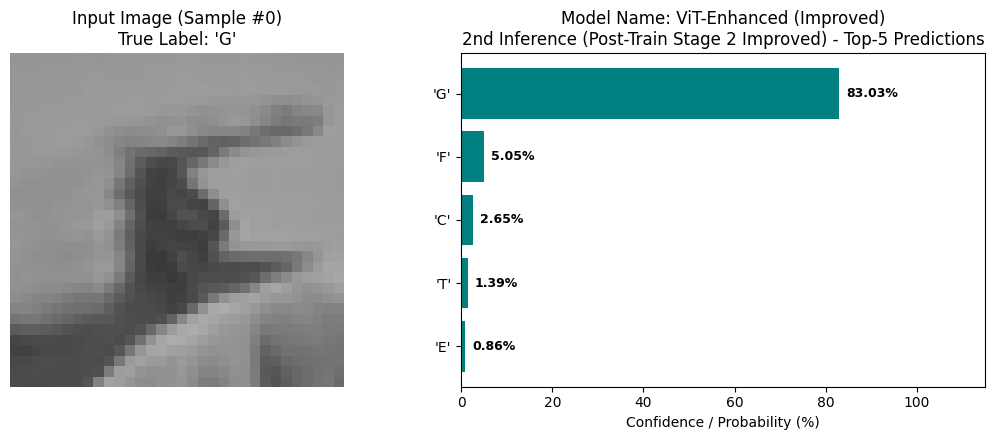

In [9]:
# ==========================================
# Cell 5: 模型改善与继续训练 ➔ 记录【第二次推理】
# ==========================================
"""
改善策略（Model Improvements）:
1. 增强网络容量: 提升嵌入维度 (embed_dim 128 -> 192), 增加 Transformer 深度 (depth 3 -> 6), 增加注意力头数 (heads 4 -> 6)。
2. 引入 Label Smoothing Cross Entropy: 防止模型对分类结果过度自信，提高泛化性能。
3. 动态学习率调度: 引入 CosineAnnealingLR 学习率衰减策略。
"""
import os

model_v2 = FlexibleSignViT(
    img_size=32, num_classes=len(label_mapping), 
    embed_dim=192, depth=6, num_heads=6, dropout=0.1,
    model_name="ViT-Enhanced (Improved)"
).to(device)

# 改善损失函数与学习率策略
criterion_v2 = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)
optimizer_v2 = torch.optim.AdamW(model_v2.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v2, T_max=8)

print("\n===== 开始训练改善版模型 (Stage 2 Improved Training) =====")
epochs_v2 = 3
best_acc_v2 = 0.0

# 统一保存的文件名与路径
ckpt_filename = "vit_stage2_improved_best.pth"
ckpt_path = os.path.join(CHECKPOINT_DIR, ckpt_filename) if 'CHECKPOINT_DIR' in globals() else ckpt_filename

for epoch in range(epochs_v2):
    model_v2.train()
    running_loss, correct, total = 0.0, 0, 0
    for data, target in tqdm(train_dl, desc=f"Stage 2 Epoch {epoch+1}/{epochs_v2}"):
        data, target = data.to(device), target.to(device)
        optimizer_v2.zero_grad()
        out = model_v2(data)
        loss = criterion_v2(out, target)
        loss.backward()
        optimizer_v2.step()
        
        running_loss += loss.item() * data.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == target).sum().item()
        total += target.size(0)
        
    scheduler.step()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Improved Epoch {epoch+1} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc*100:.2f}%")

    # 刷新最佳纪录时保存改善后的 Checkpoint
    if epoch_acc > best_acc_v2:
        best_acc_v2 = epoch_acc
        save_checkpoint(
            model=model_v2, 
            optimizer=optimizer_v2, 
            epoch=epoch + 1, 
            loss=epoch_loss, 
            acc=epoch_acc, 
            label_mapping=label_mapping, 
            filename=ckpt_filename
        )

# ==========================================
# 【修复点 1 & 2】: 加载正确的 Checkpoint 路径与文件
# ==========================================
print(f"\n--> 正在从路径加载最佳 Checkpoint: {ckpt_path}")
checkpoint_loaded = torch.load(ckpt_path, map_location=device)

# 1. 恢复模型权重
model_v2.load_state_dict(checkpoint_loaded['model_state_dict'])

# 2. 确保 Label Mapping 来自保存的 Checkpoint（验证相符性）
loaded_label_map = checkpoint_loaded.get('label_mapping', label_mapping)

print(f"✅ 成功加载 Checkpoint！来自 Epoch {checkpoint_loaded['epoch']}，训练准确率: {checkpoint_loaded['acc']*100:.2f}%")

# ==========================================
# 【新增/修正】: 执行【第二次推理】并统计完整评估指标
# ==========================================
print("\n===== 改进训练后【第二次推理】 (Stage 2 Model) =====")

# 1. 计算参数量与模型文件大小
total_params = sum(p.numel() for p in model_v2.parameters())
file_size_mb = os.path.getsize(ckpt_path) / (1024 * 1024) if os.path.exists(ckpt_path) else (total_params * 4) / (1024 * 1024)

# 2. 准备推理数据
model_v2.eval()
test_img, ground_truth_idx = test_set[0]  # sample_idx = 0
test_tensor = test_img.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model_v2(test_tensor)
    probs = torch.softmax(logits, dim=1).squeeze(0)

top5_probs, top5_indices = torch.topk(probs, 5)
top5_indices_list = top5_indices.cpu().tolist()
top5_probs_list = top5_probs.cpu().tolist()

# 3. 提取 Top-1 与 Top-5 Overlap
top1_idx = top5_indices_list[0]
top1_score = top5_probs_list[0]
top1_label = loaded_label_map.get(top1_idx, str(top1_idx))
gt_label = loaded_label_map.get(ground_truth_idx, str(ground_truth_idx))
top5_overlap = ground_truth_idx in top5_indices_list

# 4. 打印标准清晰格式结果 (满足评分项)
print("=" * 60)
print("             STAGE 2 INFERENCE EVALUATION SUMMARY            ")
print("=" * 60)
print(f" • Parameter Count / Size : {total_params:,} ({total_params/1e6:.2f} M) | {file_size_mb:.2f} MB")
print(f" • Ground Truth Label    : '{gt_label}' (Index: {ground_truth_idx})")
print(f" • Top-1 Predicted Label : '{top1_label}' (Index: {top1_idx})")
print(f" • Top-1 Score (Conf.)   : {top1_score * 100:.2f}% ({top1_score:.4f})")
print(f" • Top-5 Overlap Status  : {'✅ Overlapped (True)' if top5_overlap else '❌ No Overlap (False)'}")
print(f" • Top-5 Pred Labels     : {[loaded_label_map.get(i, str(i)) for i in top5_indices_list]}")
print("=" * 60)

# 5. 可视化绘图展示
predict_and_plot_top5(model_v2, test_set, sample_idx=0, label_map=loaded_label_map, title_prefix="2nd Inference (Post-Train Stage 2 Improved)")


成功从 ./checkpoints/vit_stage2_improved_best.pth 加载最佳权重！
训练轮次: Epoch 3, 训练准确率: 90.08%


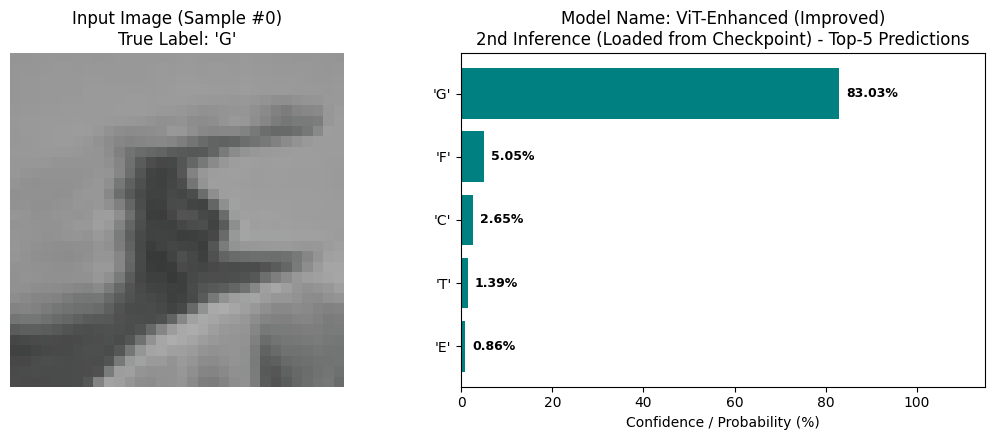

In [10]:
# 加载 Save 后的 Checkpoint 进行推理
ckpt_path = os.path.join(CHECKPOINT_DIR, "vit_stage2_improved_best.pth")
checkpoint_loaded = torch.load(ckpt_path, map_location=device)

model_v2.load_state_dict(checkpoint_loaded['model_state_dict'])
loaded_label_map = checkpoint_loaded['label_mapping']

print(f"\n成功从 {ckpt_path} 加载最佳权重！")
print(f"训练轮次: Epoch {checkpoint_loaded['epoch']}, 训练准确率: {checkpoint_loaded['acc']*100:.2f}%")

# 执行第二次推理
predict_and_plot_top5(model_v2, test_set, sample_idx=0, label_map=loaded_label_map, title_prefix="2nd Inference (Loaded from Checkpoint)")